# Football Player Evaluation Model - Analysis



## 0. Setup - Imports and Configuration

In [1]:
import pandas as pd
import tensorflow as tf

import config
from src.analysis.game_utils import game_summary
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.models.attention_lstm import AttentionLayer
from src.ml.preprocessing.sequence import SequencePreprocessor
from src.ml.xthreat import get_default_xt_model

In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
all_matches = list(data)

# Sort matches by game_date
all_matches.sort(key=lambda x: x[0].get('game_date', ''), reverse=True)

len(all_matches)


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

51

### 1.1 Validation Set Matches Information

In [4]:
matches_info = []

for match, events_df in all_matches:
    matches_info.append(game_summary(match))

for match in matches_info:
    print(match)


Spain 2 : 1 England (Final) [14.07.2024]
Netherlands 1 : 2 England (Semi-finals) [10.07.2024]
Spain 2 : 1 France (Semi-finals) [09.07.2024]
Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024]
England 1 : 1 Switzerland (Quarter-finals) [06.07.2024]
Portugal 0 : 0 France (Quarter-finals) [05.07.2024]
Spain 2 : 1 Germany (Quarter-finals) [05.07.2024]
Austria 1 : 2 Turkey (Round of 16) [02.07.2024]
Romania 0 : 3 Netherlands (Round of 16) [02.07.2024]
Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024]
France 1 : 0 Belgium (Round of 16) [01.07.2024]
Spain 4 : 1 Georgia (Round of 16) [30.06.2024]
England 2 : 1 Slovakia (Round of 16) [30.06.2024]
Germany 2 : 0 Denmark (Round of 16) [29.06.2024]
Switzerland 2 : 0 Italy (Round of 16) [29.06.2024]
Czech Republic 1 : 2 Turkey (Group Stage) [26.06.2024]
Georgia 2 : 0 Portugal (Group Stage) [26.06.2024]
Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]
Slovakia 1 : 1 Romania (Group Stage) [26.06.2024]
Denmark 0 : 0 Serbia (Group Stage) [25.06.2024

## 2. Load Trained Model

In [5]:
# Load the best trained model
model_path = f"models/{config.MODEL_TYPE}/best_model.keras"
model = tf.keras.models.load_model(model_path, custom_objects={'AttentionLayer': AttentionLayer})
print(f"Model loaded from: {model_path}")
print(f"Model type: {config.MODEL_TYPE}")


Model loaded from: models/attention_lstm/best_model.keras
Model type: attention_lstm


In [6]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 6, 45)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │       178,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_weights               │ [(None, 128), (None,   │           134 │
│ (AttentionLayer)                │ 6)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ value (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,151,255 (4.39 MB)

 Trainable params: 383,751 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 767,504 (2.93 MB)

## 3. Preprocess Data for Analysis

In [7]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p, m = preprocessor.process_matches(all_matches)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events
 → Generated 86 sequences, 86 labels for match 3943043
→Processing match 3942819: 3485 events
 → Generated 82 sequences, 82 labels for match 3942819
→Processing match 3942752: 3328 events
 → Generated 107 sequences, 107 labels for match 3942752
→Processing match 3942382: 3415 events
 → Generated 91 sequences, 91 labels for match 3942382
→Processing match 3942227: 4882 events
 → Generated 105 sequences, 105 labels for match 3942227
→Processing match 3942349: 5190 events
 → Generated 131 sequences, 131 labels for match 3942349
→Processing match 3942226: 4463 events
 → Generated 138 sequences, 138 labels for match 3942226
→Processing match 3941022: 3722 events
 → Generated 104 sequences, 104 labels for match 3941022
→Processing match 3941021: 2996 events
 → Generated 98 sequences, 98 labels for match 3941021
→Processing match 3941020: 4221 events
 → Generated 124 sequences, 124 labels for match 3941020
→Processing match 3941019: 3941 events
 → Genera

In [8]:
X.shape

(5277, 6, 45)

In [9]:
p.shape

(5277,)

In [10]:
p[0:200]

array([  3,   4,   5,   6,   7,   8,   9,  12,  15,  17,  19,  21,  24,
        26,  27,  29,  30,  31,  32,  33,  34,  36,  40,  42,  43,  44,
        46,  48,  49,  50,  51,  52,  56,  58,  60,  61,  62,  63,  64,
        65,  66,  67,  69,  74,  79,  80,  81,  83,  84,  85,  87,  89,
        90,  91,  92,  94,  96,  97,  98,  99, 100, 102, 104, 105, 106,
       109, 110, 111, 112, 113, 117, 119, 120, 121, 123, 125, 127, 129,
       130, 132, 133, 134, 135, 136, 137, 144,   2,   4,   5,   6,   7,
         8,   9,  10,  11,  12,  13,  16,  17,  18,  22,  23,  24,  26,
        27,  28,  30,  31,  32,  33,  34,  36,  38,  40,  42,  44,  45,
        47,  48,  49,  51,  52,  53,  54,  55,  56,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  70,  71,  72,  73,  74,  75,
        76,  77,  79,  81,  85,  86,  88,  89,  90,  92,  93,  94,  95,
        96,  97,  98,  99, 100, 103, 104, 106, 109, 110, 111, 113,   2,
         3,   4,   5,   7,   8,   9,  11,  12,  13,  14,  15,  1

## 4. Analysis


### 4.1 Single Match Analysis - Final Match

#### Load and analyze the final match

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from src.ml.preprocessing.possessions_extraction import extract_possessions, tail_dataframes_to_sequence_length
selected_match, selected_events = all_matches[0]
selected_match_id = selected_match.get('match_id', selected_match.get('game_id', 'N/A'))

print(f"\nAnalyzing match: {game_summary(selected_match)}")
print(f"Events in match: {len(selected_events)}")



Analyzing match: Spain 2 : 1 England (Final) [14.07.2024]
Events in match: 3312


#### Preprocess match into sequences

In [12]:
preprocessor_analysis = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

X_match, y_match, p_match = preprocessor_analysis.process_match(selected_match_id, selected_match, selected_events)
print(f"Created {len(X_match)} sequences from {len(selected_events)} events")


→Processing match 3943043: 3312 events
 → Generated 86 sequences, 86 labels for match 3943043
Created 86 sequences from 3312 events


#### Make predictions on match sequences

In [13]:
predictions = model.predict(X_match, batch_size=32, verbose=0)

predicted_values = predictions['value'].flatten()
attention_weights = predictions['attention_weights']  # Shape: (n_sequences, sequence_length)

print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")


Total sequences analyzed: 86
Sum of all predicted values: 2.418


#### Get top 8 sequences by predicted value

In [14]:
from src.analysis.prediction_utils import get_top_indices

number_of_top_predictions = 8
top_indices = get_top_indices(predicted_values, number_of_top_predictions)

print(f"\nTop {number_of_top_predictions} sequences with highest predicted values:\n")
for i, idx in enumerate(top_indices):
    seq_value = predicted_values[idx]
    seq_weights = attention_weights[idx]
    possession_id = p_match[idx]
    max_weight_idx = np.argmax(seq_weights)

    print(f"{i + 1}. Sequence with possession id = {possession_id}: Value = {seq_value:.3f}")
    print(f"   Attention weights: {[f'{w:.3f}' for w in seq_weights]}")
    print(f"   Most important action: position {max_weight_idx} (weight: {seq_weights[max_weight_idx]:.3f})")
    print()



Top 8 sequences with highest predicted values:

1. Sequence with possession id = 136: Value = 0.248
   Attention weights: ['0.166', '0.178', '0.183', '0.174', '0.160', '0.140']
   Most important action: position 2 (weight: 0.183)

2. Sequence with possession id = 81: Value = 0.210
   Attention weights: ['0.151', '0.165', '0.179', '0.182', '0.171', '0.151']
   Most important action: position 3 (weight: 0.182)

3. Sequence with possession id = 117: Value = 0.173
   Attention weights: ['0.155', '0.164', '0.180', '0.183', '0.171', '0.147']
   Most important action: position 3 (weight: 0.183)

4. Sequence with possession id = 83: Value = 0.142
   Attention weights: ['0.175', '0.172', '0.178', '0.170', '0.159', '0.146']
   Most important action: position 2 (weight: 0.178)

5. Sequence with possession id = 69: Value = 0.106
   Attention weights: ['0.158', '0.163', '0.177', '0.180', '0.169', '0.153']
   Most important action: position 3 (weight: 0.180)

6. Sequence with possession id = 105: V

#### Visualize top 8 possessions on the pitch

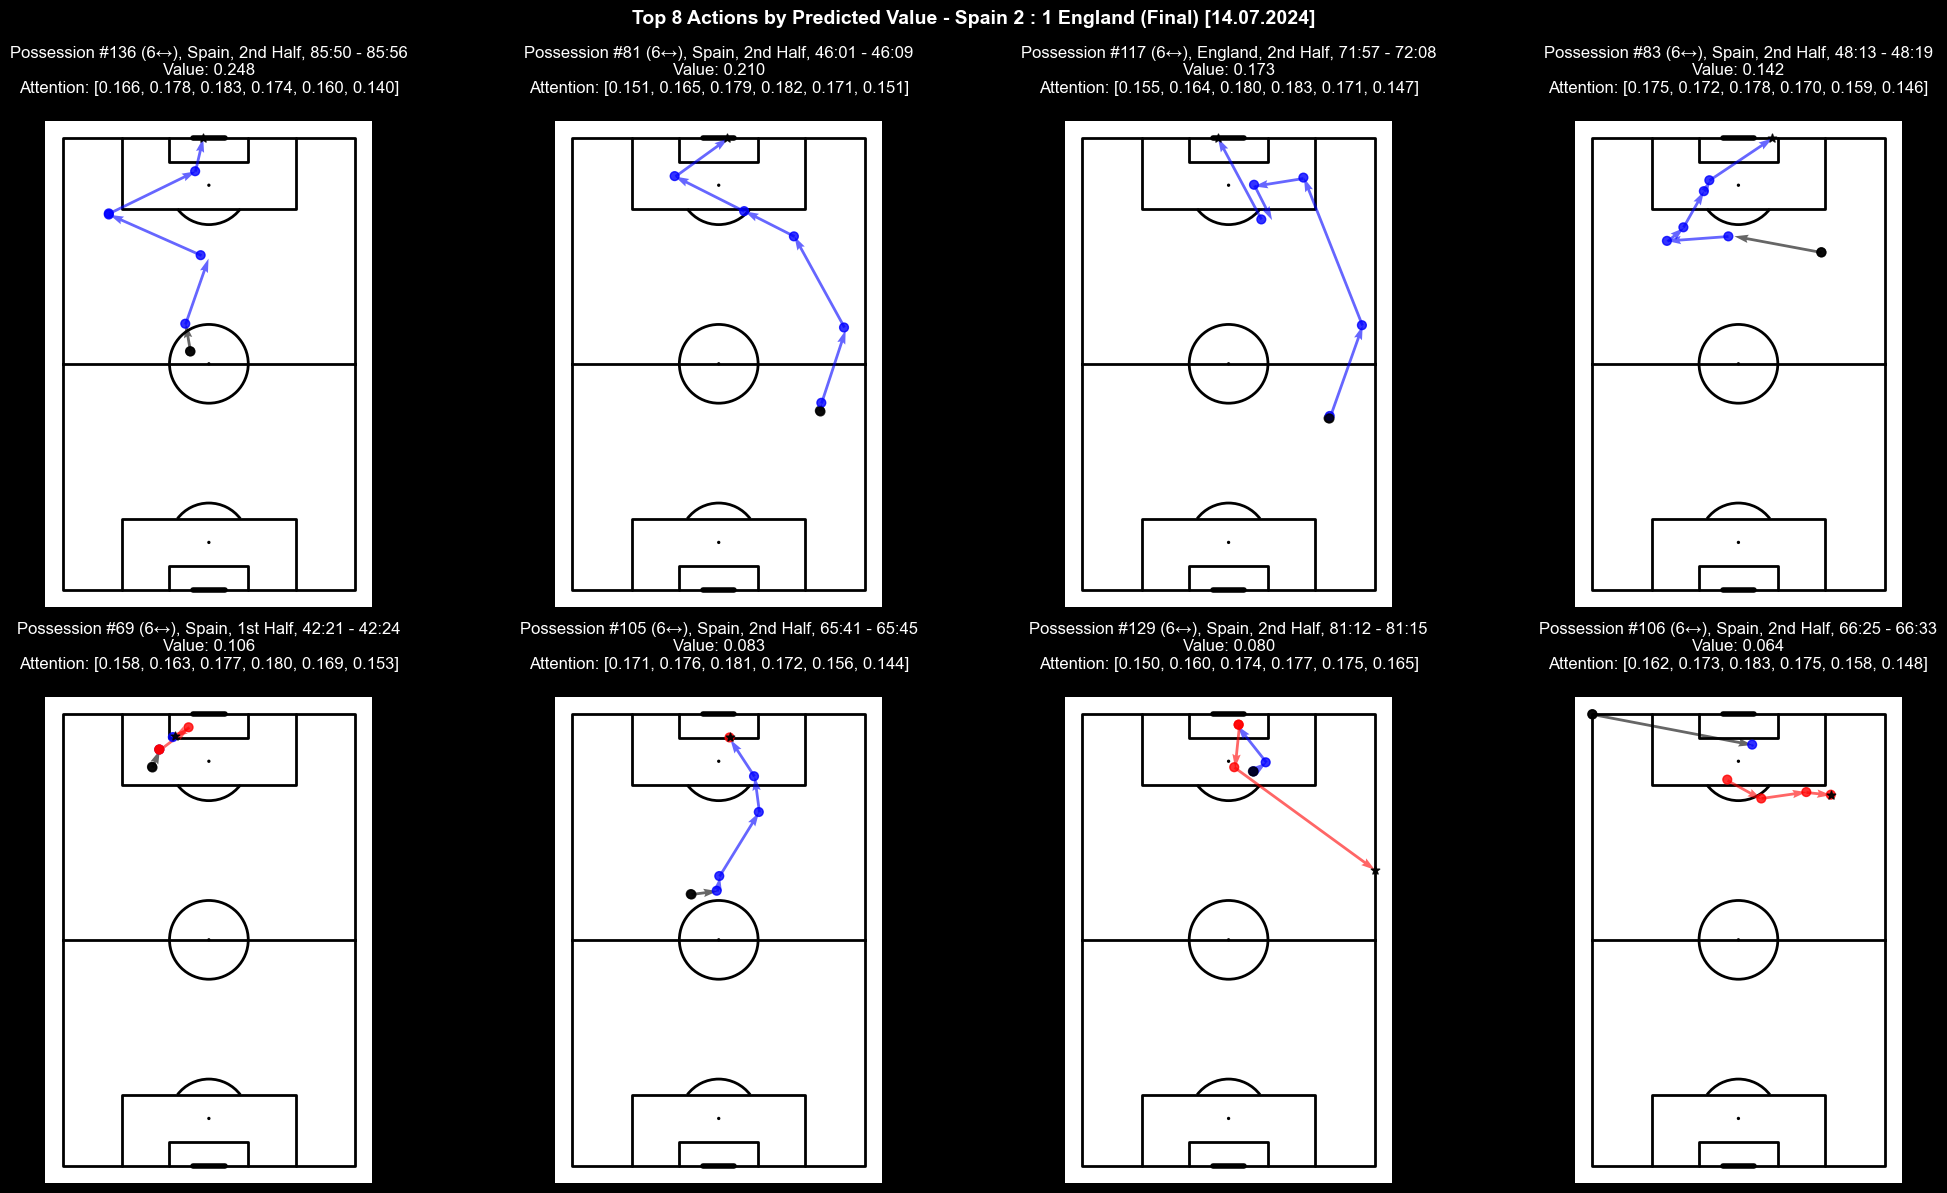

In [15]:
from src.analysis.visualization import plot_multiple_possessions, _title_with_value

top_possessions = [extract_possessions(selected_match, selected_events)[p_match[idx]] for idx in top_indices]
top_possessions = tail_dataframes_to_sequence_length(top_possessions, config.SEQUENCE_LENGTH)

top_possession_titles = []
for i, idx in enumerate(top_indices):
    possession = top_possessions[i]
    attention_weight = attention_weights[idx]
    top_possession_titles.append(_title_with_value(possession, predicted_values[idx], attention_weight))

fig = plot_multiple_possessions(top_possessions, titles=top_possession_titles,
                                main_title=f"Top {number_of_top_predictions} Actions by Predicted Value - {game_summary(selected_match)}")
plt.tight_layout()
plt.show()


### 4.2 All Matches Analysis

#### Extract match information from all matches

In [16]:
from src.analysis.prediction_utils import matches_info_df

matches_df = matches_info_df(all_matches)
matches_df.head(10)

,match_id,summary,events_count
0,3943043,Spain 2 : 1 England (Final) [14.07.2024],3312
1,3942819,Netherlands 1 : 2 England (Semi-finals) [10.07.2024],3485
2,3942752,Spain 2 : 1 France (Semi-finals) [09.07.2024],3328
3,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024],3415
4,3942227,England 1 : 1 Switzerland (Quarter-finals) [06.07.2024],4882
5,3942349,Portugal 0 : 0 France (Quarter-finals) [05.07.2024],5190
6,3942226,Spain 2 : 1 Germany (Quarter-finals) [05.07.2024],4463
7,3941022,Austria 1 : 2 Turkey (Round of 16) [02.07.2024],3722
8,3941021,Romania 0 : 3 Netherlands (Round of 16) [02.07.2024],2996
9,3941020,Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024],4221


#### Predictions for all matches

In [17]:
predictions = model.predict(X, batch_size=32, verbose=0)

In [18]:
predicted_values = predictions['value'].flatten()
predicted_values

array([0.00742811, 0.01230797, 0.00568672, ..., 0.01029739, 0.00285526,
       0.08627843], dtype=float32)

In [19]:
attention_weights = predictions['attention_weights']
attention_weights


array([[0.16018155, 0.1634605 , 0.16804202, 0.16632135, 0.16701624,
        0.1749784 ],
       [0.16707139, 0.17422749, 0.17876199, 0.17219329, 0.16055062,
        0.14719525],
       [0.18201433, 0.17979121, 0.18244478, 0.16956265, 0.15202336,
        0.1341636 ],
       ...,
       [0.15695004, 0.16715522, 0.18044549, 0.17625533, 0.16398437,
        0.15520962],
       [0.18474527, 0.18737592, 0.1865342 , 0.16708799, 0.14509608,
        0.12916055],
       [0.17274657, 0.17980593, 0.18714546, 0.17278051, 0.15389395,
        0.1336276 ]], dtype=float32)

#### Get top 8 sequences by predicted value across all matches

In [20]:
from src.analysis.prediction_utils import get_top_indices

number_of_top_predictions = 8
top_indices = get_top_indices(predicted_values)

print(f"\nTop {number_of_top_predictions} sequences with highest predicted values across validation set:\n")
for rank, idx in enumerate(top_indices[:number_of_top_predictions], 1):
    seq_value = predicted_values[idx]
    seq_weights = attention_weights[idx]
    possession_id = p[idx]
    match_id = m[idx]
    max_weight_idx = np.argmax(seq_weights)

    print(f"{rank}. Match ID = {match_id}, Possession ID = {possession_id}: Value = {seq_value:.3f}")
    print(f"   Attention weights: {[f'{w:.3f}' for w in seq_weights]}")
    print(f"   Most important action: position {max_weight_idx} (weight: {seq_weights[max_weight_idx]:.3f})")
    print()



Top 8 sequences with highest predicted values across validation set:

1. Match ID = 3930160, Possession ID = 105: Value = 1.079
   Attention weights: ['0.222', '0.192', '0.174', '0.148', '0.134', '0.131']
   Most important action: position 0 (weight: 0.222)

2. Match ID = 3938638, Possession ID = 93: Value = 0.860
   Attention weights: ['0.208', '0.193', '0.175', '0.162', '0.141', '0.121']
   Most important action: position 0 (weight: 0.208)

3. Match ID = 3930170, Possession ID = 69: Value = 0.807
   Attention weights: ['0.203', '0.186', '0.173', '0.154', '0.149', '0.134']
   Most important action: position 0 (weight: 0.203)

4. Match ID = 3930174, Possession ID = 90: Value = 0.776
   Attention weights: ['0.200', '0.184', '0.175', '0.167', '0.147', '0.128']
   Most important action: position 0 (weight: 0.200)

5. Match ID = 3930184, Possession ID = 107: Value = 0.596
   Attention weights: ['0.187', '0.176', '0.177', '0.172', '0.150', '0.138']
   Most important action: position 0 (wei

#### Prepare possessions for all matches

In [21]:
from src.analysis.prediction_utils import create_possessions_list
import gc

game_possessions_list = create_possessions_list(all_matches)
del all_matches
gc.collect()

0

#### Visualize top 8 possessions from validation set on the pitch

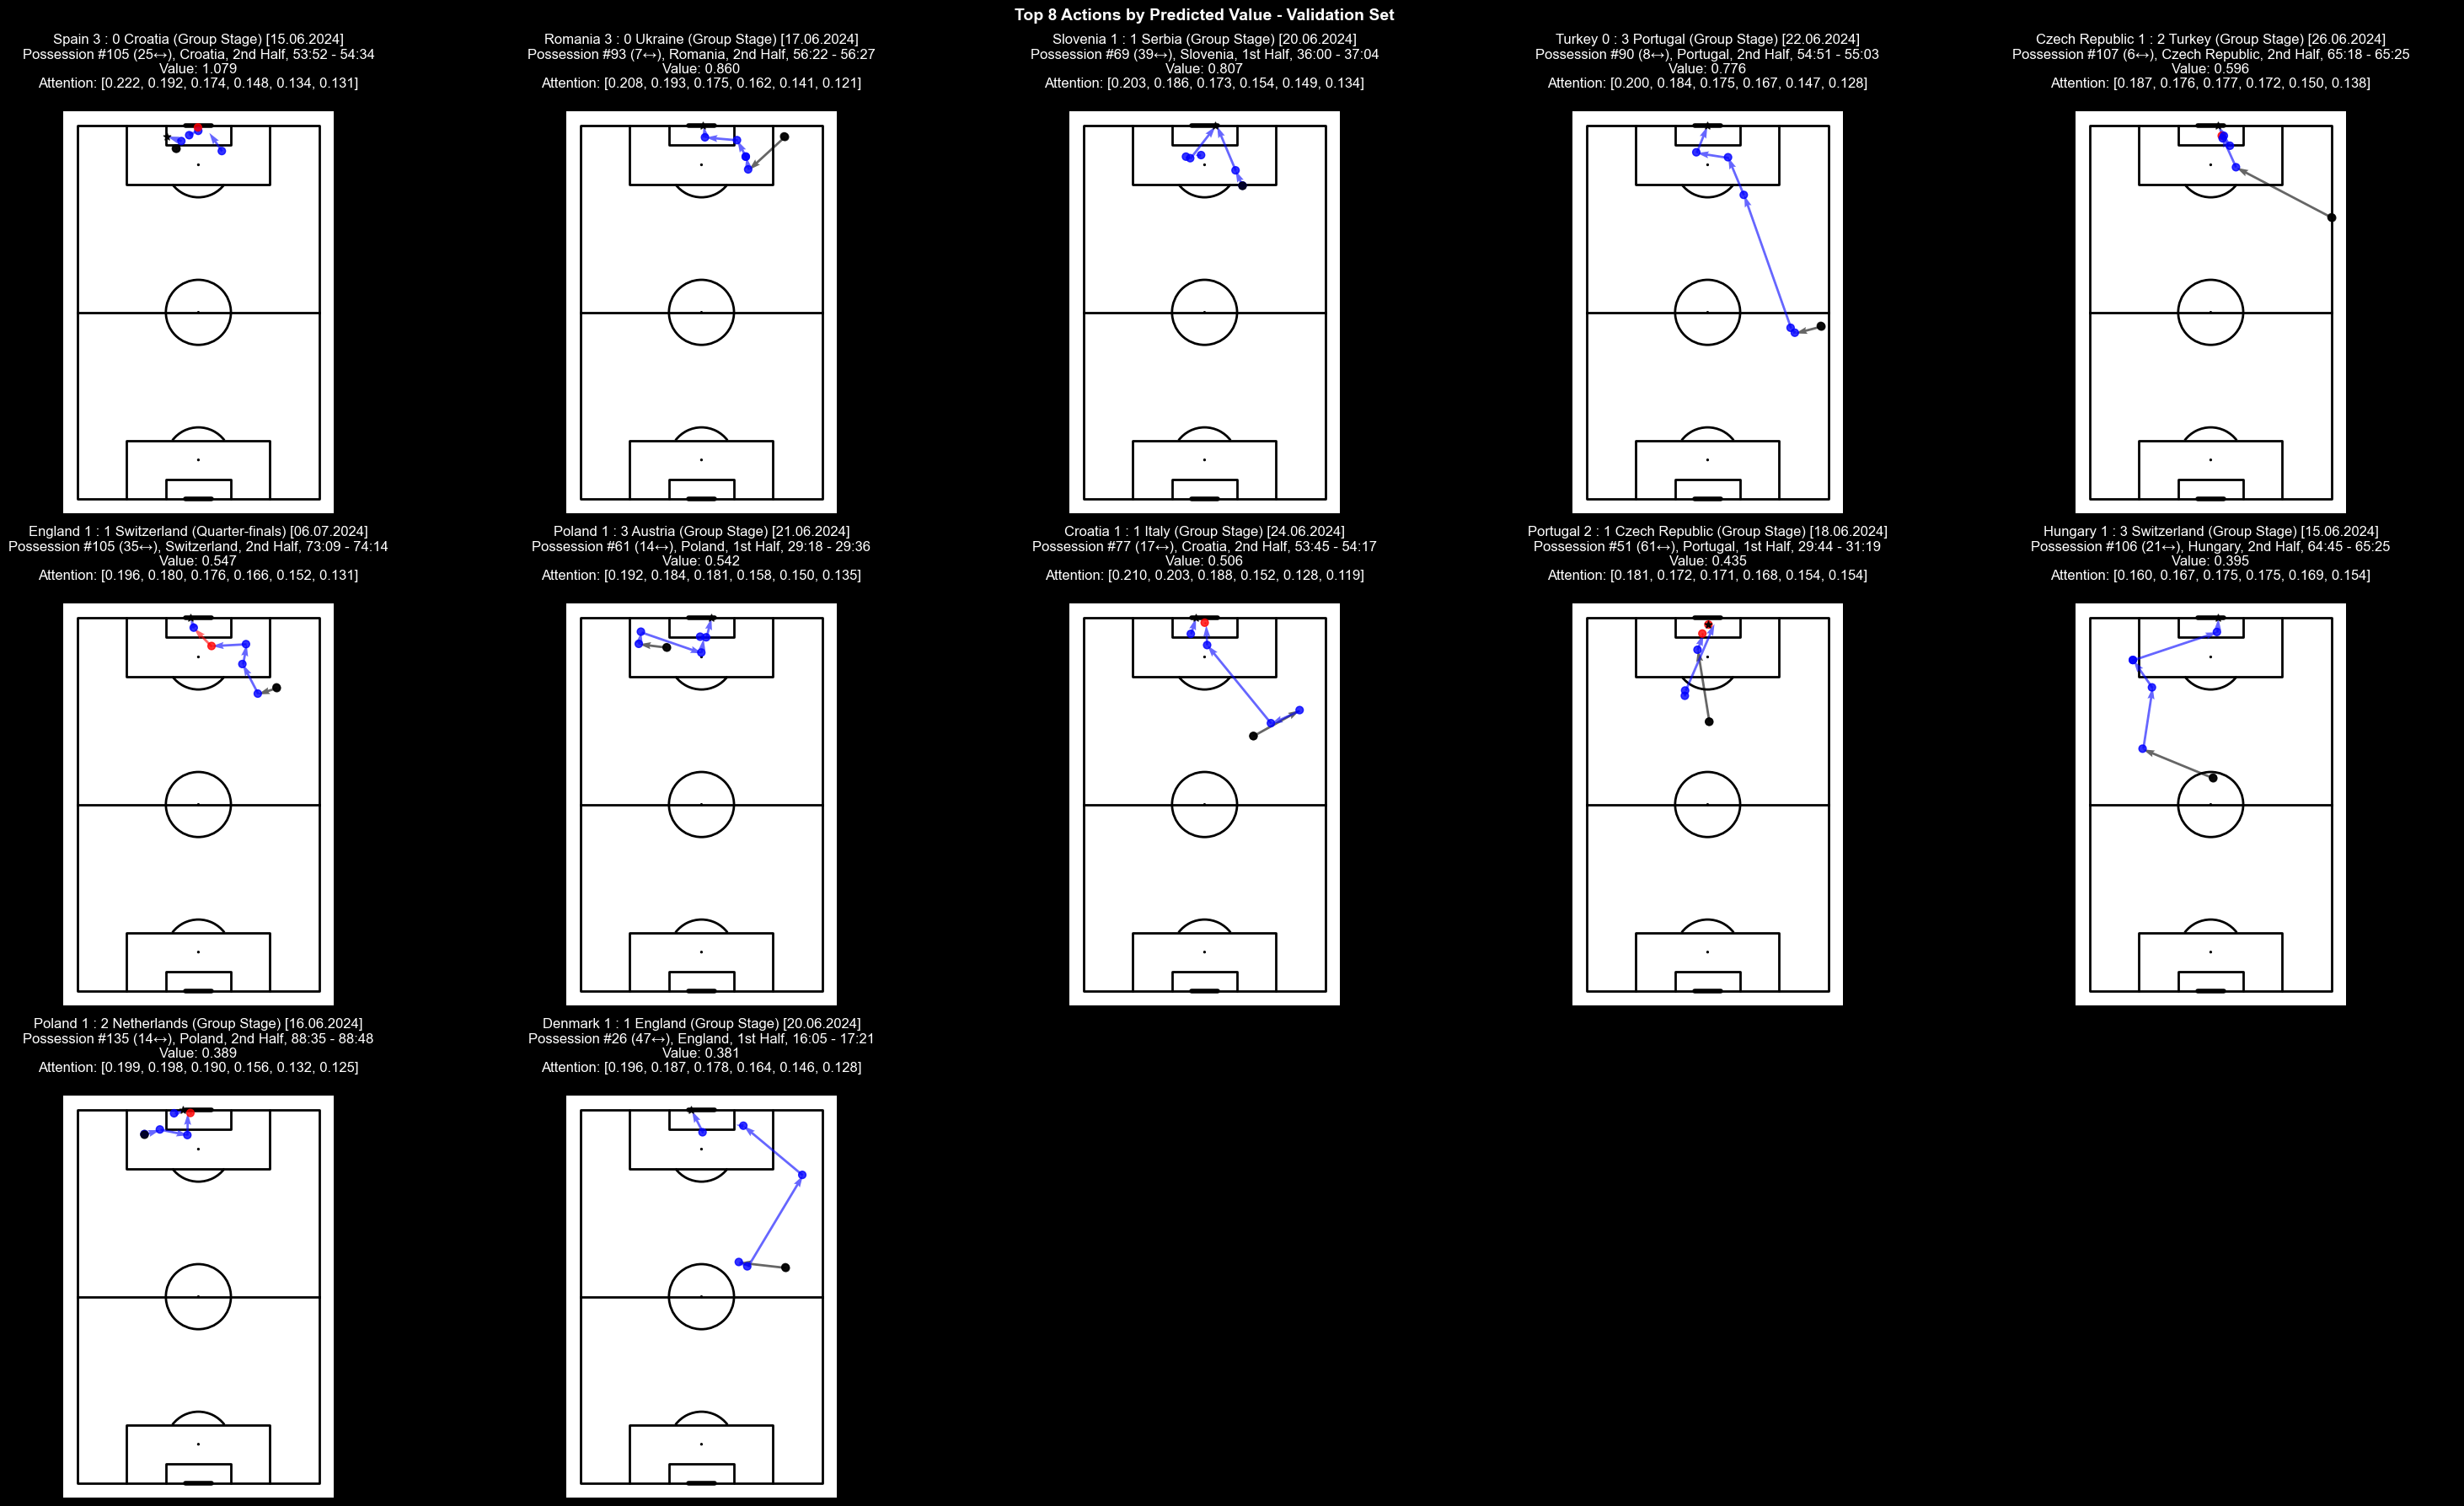

In [22]:
top_possessions_all = []
top_possession_titles_all = []

for idx in top_indices[:12]:
    possession_id = p[idx]
    match_id = int(m[idx])

    match, possessions = [item for item in game_possessions_list if item[0]['game_id'] == match_id][0]

    top_possessions_all.append(possessions[possession_id])

    value = game_summary(match) + "\n" +  _title_with_value(possessions[possession_id], predicted_values[idx], attention_weights[idx])
    top_possession_titles_all.append(value)

top_possessions_all = tail_dataframes_to_sequence_length(top_possessions_all, config.SEQUENCE_LENGTH)
fig = plot_multiple_possessions(top_possessions_all, titles=top_possession_titles_all,
                                main_title=f"Top {number_of_top_predictions} Actions by Predicted Value - Validation Set")
plt.tight_layout()
plt.show()